In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/davibaca/study-xgb/permutation_result.pkl
/kaggle/input/datasets/davibaca/study-xgb/model_xgb.pkl
/kaggle/input/datasets/davibaca/study-xgb/study_xgb_target.pkl
/kaggle/input/datasets/davibaca/study-xgb/study_xgb_onehot.pkl
/kaggle/input/datasets/davibaca/study-xgb/study_xgb (1).pkl
/kaggle/input/playground-series-s5e1/sample_submission.csv
/kaggle/input/playground-series-s5e1/train.csv
/kaggle/input/playground-series-s5e1/test.csv


In [2]:
!pip install -U optuna
import optuna
print(optuna.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 6.7 MB/s eta 0:00:00
  Attempting uninstall: optuna
    Found existing installation: optuna 4.1.0
    Uninstalling optuna-4.1.0:
      Successfully uninstalled optuna-4.1.0
5.0.0


In [3]:
!pip install -U scikit-learn
import sklearn
print(sklearn.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 60.7 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.2 which is incompatible.
1.7.2


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
color_pal = sns.color_palette()

In [5]:
# Create functions

# Time series features
def create_features(df):
    df = df.copy()
    df['dayofweek'] = df['date'].dt.dayofweek
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofmonth'] = df['date'].dt.day
    df['weekofyear'] = df['date'].dt.isocalendar().week
    return df


In [6]:
# DataFrame with training data
train_df = pd.read_csv('/kaggle/input/playground-series-s5e1/train.csv', parse_dates=["date"])
train_df.head()

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0


In [7]:
# DataFrame with testing data
test_df = pd.read_csv('/kaggle/input/playground-series-s5e1/test.csv',parse_dates=["date"])
test_df.head()


,id,date,country,store,product
0,230130,2017-01-01,Canada,Discount Stickers,Holographic Goose
1,230131,2017-01-01,Canada,Discount Stickers,Kaggle
2,230132,2017-01-01,Canada,Discount Stickers,Kaggle Tiers
3,230133,2017-01-01,Canada,Discount Stickers,Kerneler
4,230134,2017-01-01,Canada,Discount Stickers,Kerneler Dark Mode


# Data analysis

In [8]:
#Type of variables
train_df.dtypes

id                   int64
date        datetime64[ns]
country             object
store               object
product             object
num_sold           float64
dtype: object

Three variables type object, one type date time. Dependent variable type numeric

In [9]:
train_df["country"].value_counts()

country
Canada       38355
Finland      38355
Italy        38355
Kenya        38355
Norway       38355
Singapore    38355
Name: count, dtype: int64

In [10]:
train_df.groupby('country')['num_sold'].sum()

country
Canada       28653095.0
Finland      28698872.0
Italy        20797669.0
Kenya          689141.0
Norway       54562305.0
Singapore    33102374.0
Name: num_sold, dtype: float64

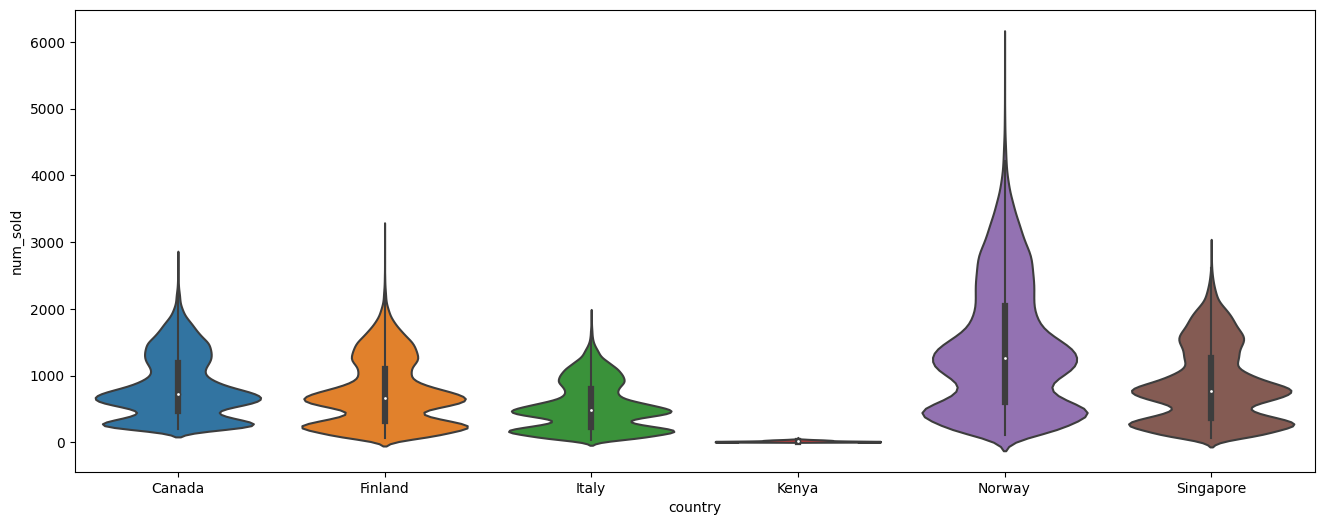

In [11]:
plt.figure(figsize=(16, 6))

sns.violinplot(x='country', y='num_sold', data=train_df, scale='width')

plt.show()

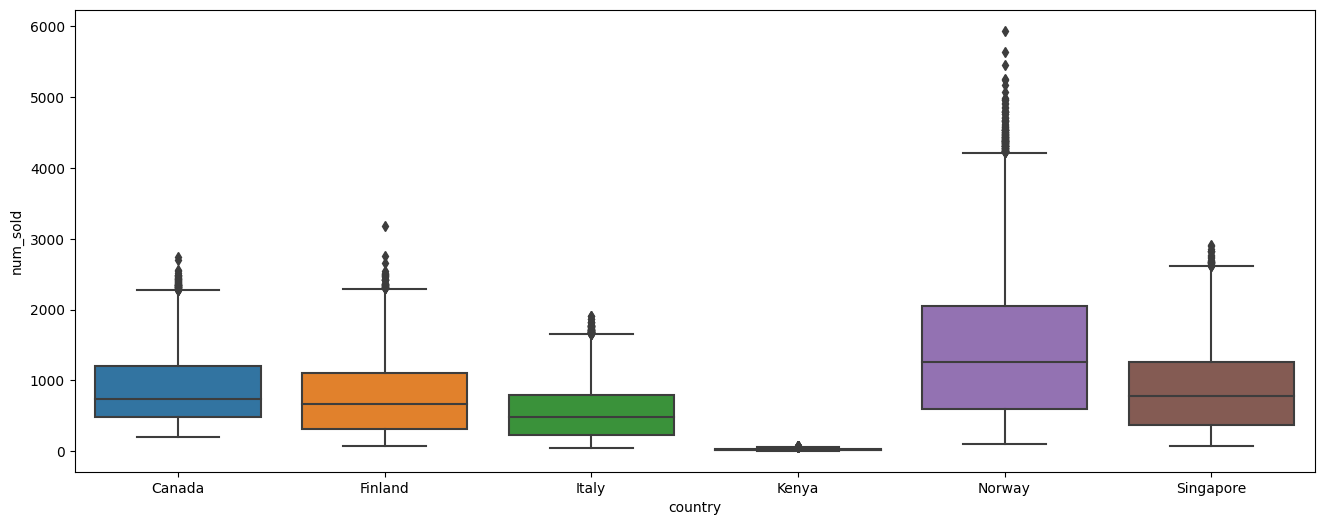

In [12]:
plt.figure(figsize=(16, 6))

sns.boxplot(x='country', y='num_sold', data=train_df)

plt.show()

In [13]:
train_df["store"].value_counts()

store
Discount Stickers       76710
Stickers for Less       76710
Premium Sticker Mart    76710
Name: count, dtype: int64

In [14]:
train_df.groupby('store')['num_sold'].sum()

store
Discount Stickers       30599237.0
Premium Sticker Mart    73703822.0
Stickers for Less       62200397.0
Name: num_sold, dtype: float64

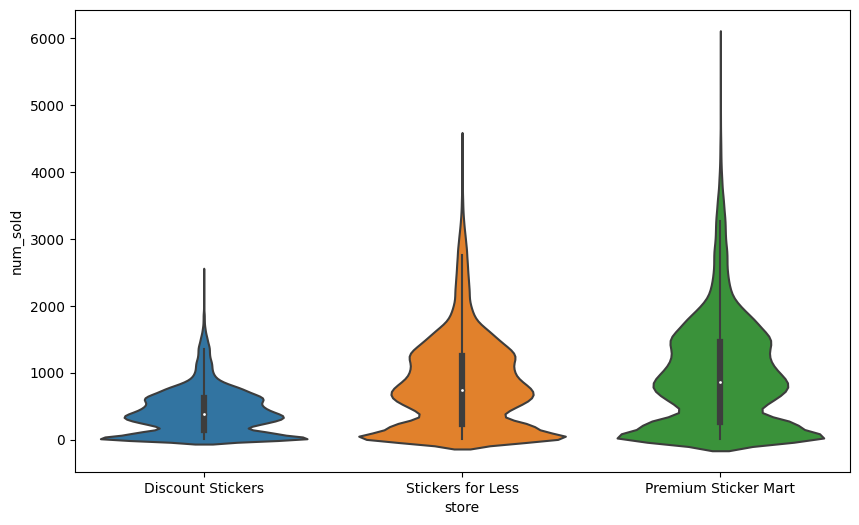

In [15]:
plt.figure(figsize=(10, 6))

sns.violinplot(x='store', y='num_sold', data=train_df, scale='width')

plt.show()

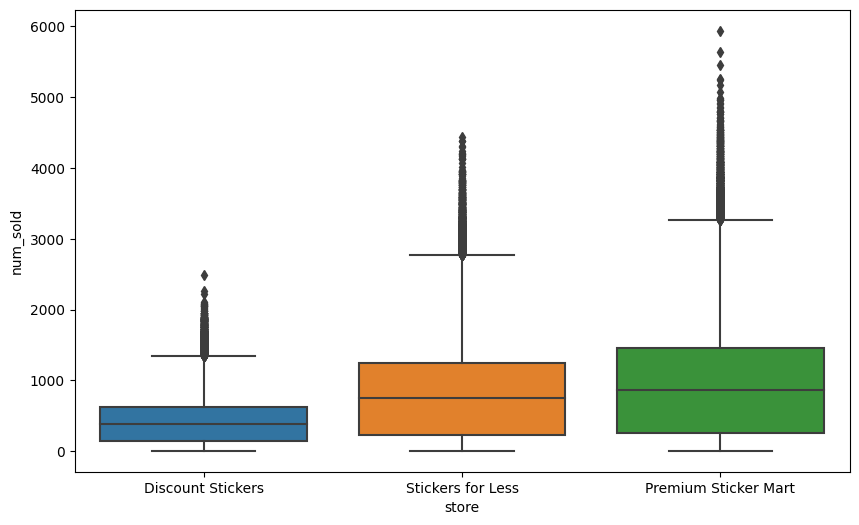

In [16]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='store', y='num_sold', data=train_df)

plt.show()

In [17]:
train_df["product"].value_counts()

product
Holographic Goose     46026
Kaggle                46026
Kaggle Tiers          46026
Kerneler              46026
Kerneler Dark Mode    46026
Name: count, dtype: int64

In [18]:
train_df.groupby('product')['num_sold'].sum()

product
Holographic Goose      7350368.0
Kaggle                56721733.0
Kaggle Tiers          46870306.0
Kerneler              25596840.0
Kerneler Dark Mode    29964209.0
Name: num_sold, dtype: float64

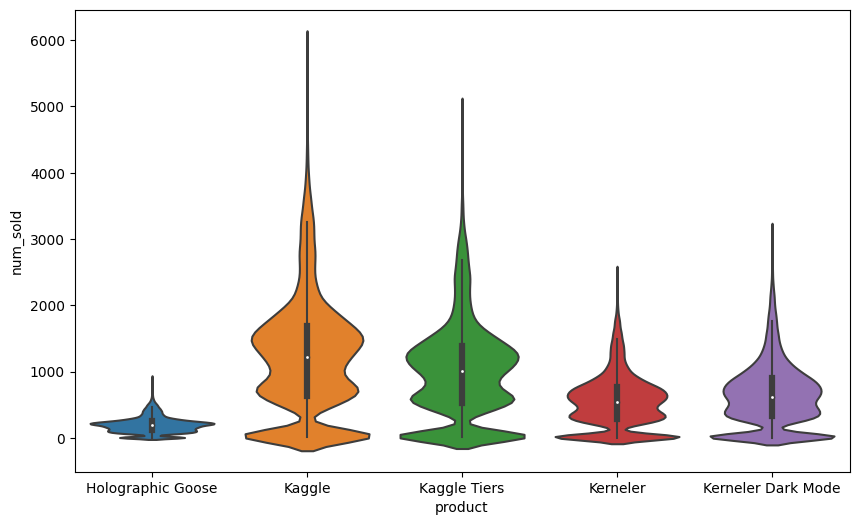

In [19]:
plt.figure(figsize=(10, 6))

sns.violinplot(x='product', y='num_sold', data=train_df, scale='width')

plt.show()

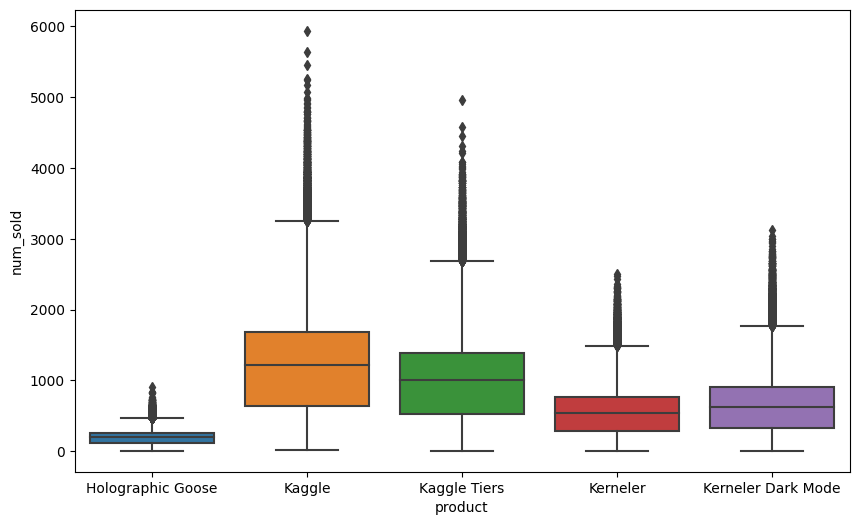

In [20]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='product', y='num_sold', data=train_df)

plt.show()

The variables country, store and product are categorical nominal variables.

The variable country has 6 levels, store has 3 levels and product has 5 levels

# NAs

<Axes: xlabel='product', ylabel='country'>

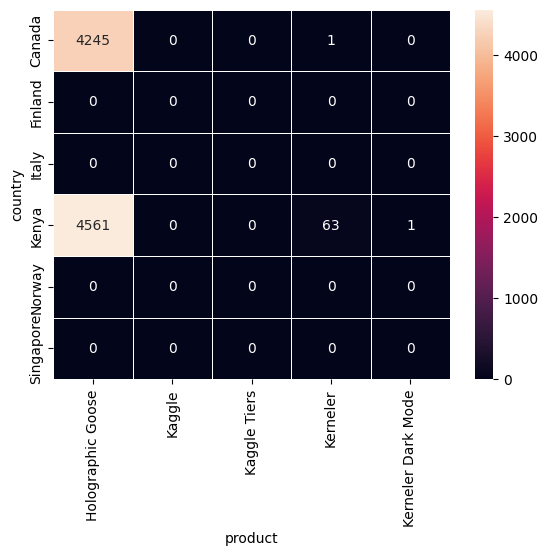

In [21]:
nas_matrix = pd.crosstab(
    index=train_df['country'],
    columns=train_df['product'],  
    values=train_df['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)

sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)


<Axes: xlabel='store', ylabel='country'>

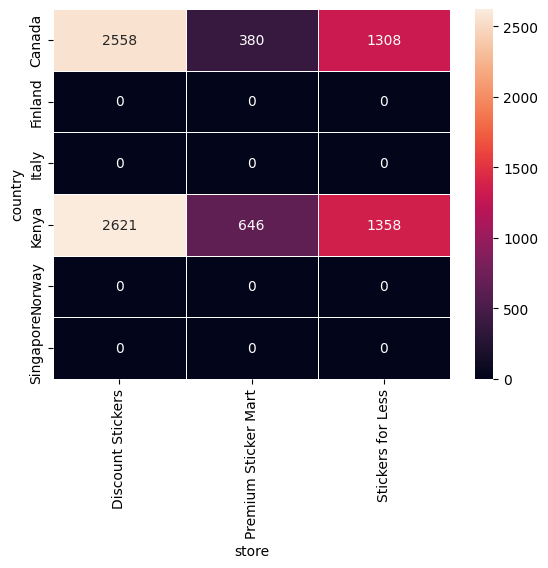

In [22]:
nas_matrix = pd.crosstab(
    index=train_df['country'],
    columns=train_df['store'],  
    values=train_df['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)

sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)


<Axes: xlabel='product', ylabel='store'>

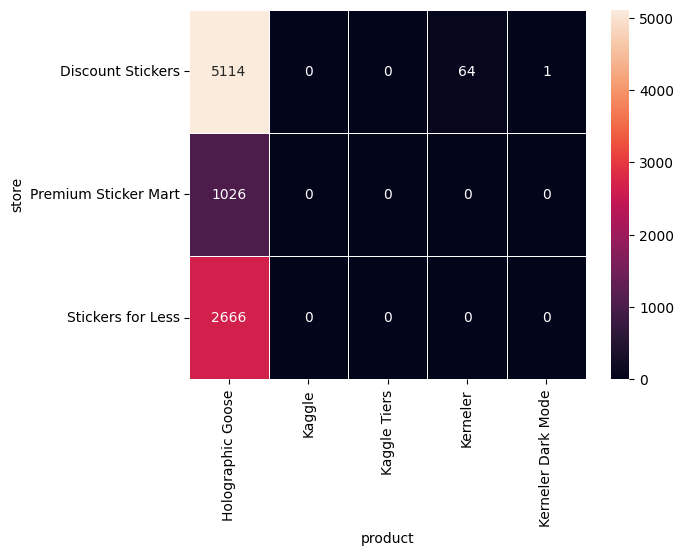

In [23]:
nas_matrix = pd.crosstab(
    index=train_df['store'],
    columns=train_df['product'],  
    values=train_df['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)

sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)


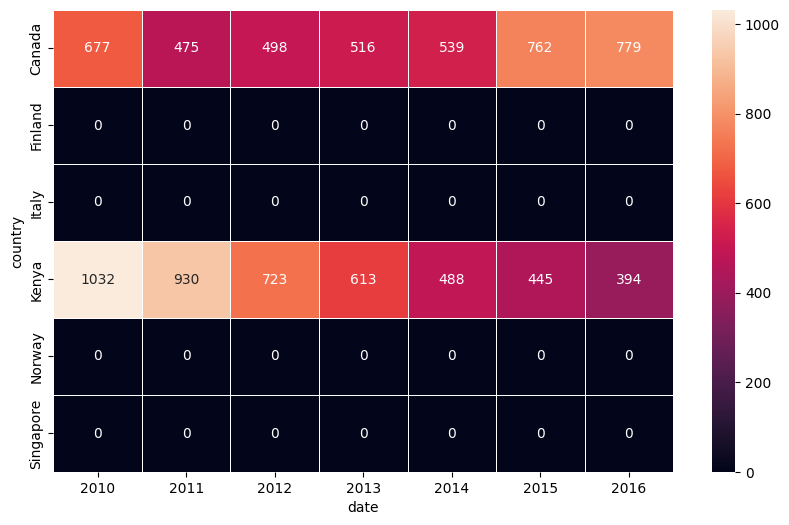

In [24]:
nas_matrix = pd.crosstab(
    index=train_df['country'],
    columns=train_df['date'].dt.year,
    values=train_df['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)
plt.figure(figsize=(10, 6))

sns.heatmap(
    nas_matrix,
    annot=True,
    fmt='g',
    linewidths=0.5,
)
plt.show()

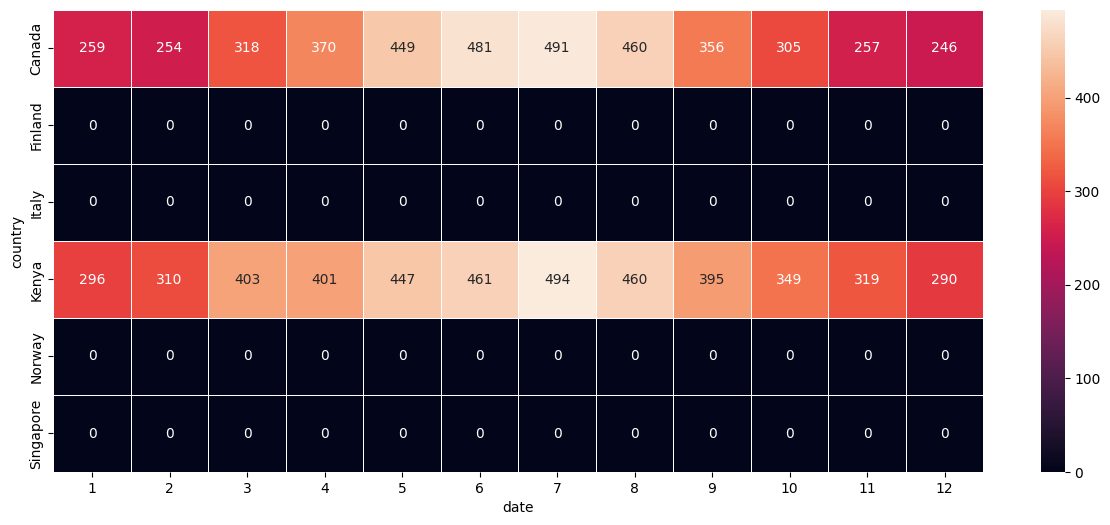

In [25]:
nas_matrix = pd.crosstab(
    index=train_df['country'],
    columns=train_df['date'].dt.month,
    values=train_df['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)
plt.figure(figsize=(15, 6))
sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)
plt.show()

It seems that there is a patron in the data loss Canda and Kenya had lost the same product (holographic goose). The store which had lost more data is Discount Stickers followed by Stickers for Less and Premium Sticker Mart. There also seems to be a patron with year, where first years of data get more lost.

We are going to look closer to Canada and Kenya

In [26]:
df_Canada = train_df[train_df['country']=='Canada'].copy()
df_Kenya = train_df[train_df['country']=='Kenya'].copy()

<Axes: xlabel='product', ylabel='store'>

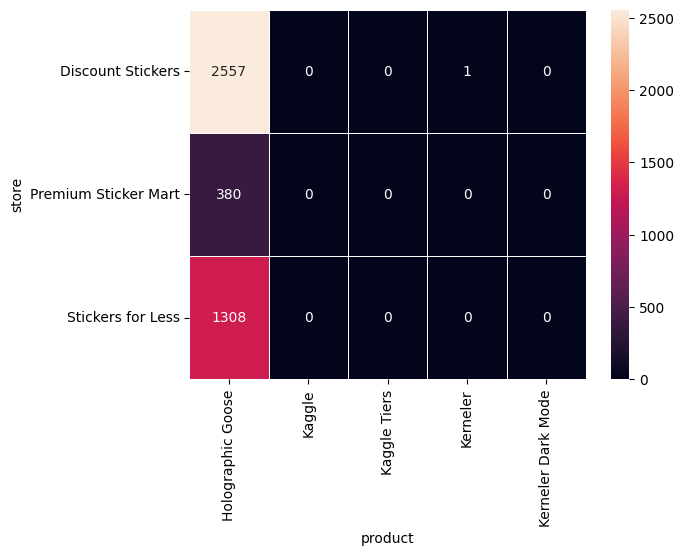

In [27]:
nas_matrix = pd.crosstab(
    index=df_Canada['store'],
    columns=df_Canada['product'],  
    values=df_Canada['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)

sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)

<Axes: xlabel='product', ylabel='store'>

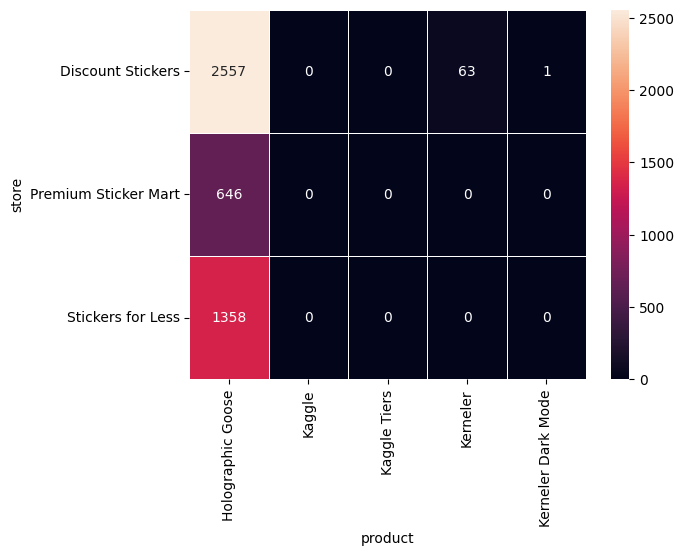

In [28]:
nas_matrix = pd.crosstab(
    index=df_Kenya['store'],
    columns=df_Kenya['product'],  
    values=df_Kenya['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)

sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)

In [29]:
group_means = train_df.groupby(['product', 'country','store'])['num_sold'].mean().to_dict()
group_means

{('Holographic Goose', 'Canada', 'Discount Stickers'): nan,
 ('Holographic Goose', 'Canada', 'Premium Sticker Mart'): 248.3821773082223,
 ('Holographic Goose', 'Canada', 'Stickers for Less'): 228.8166533226581,
 ('Holographic Goose', 'Finland', 'Discount Stickers'): 98.00156433320298,
 ('Holographic Goose', 'Finland', 'Premium Sticker Mart'): 235.26046147829487,
 ('Holographic Goose', 'Finland', 'Stickers for Less'): 198.95580758701604,
 ('Holographic Goose', 'Italy', 'Discount Stickers'): 70.84630426280798,
 ('Holographic Goose', 'Italy', 'Premium Sticker Mart'): 170.38287055142746,
 ('Holographic Goose', 'Italy', 'Stickers for Less'): 144.0183809151349,
 ('Holographic Goose', 'Kenya', 'Discount Stickers'): nan,
 ('Holographic Goose', 'Kenya', 'Premium Sticker Mart'): 5.941915227629513,
 ('Holographic Goose', 'Kenya', 'Stickers for Less'): 5.470391993327773,
 ('Holographic Goose', 'Norway', 'Discount Stickers'): 186.7258506061791,
 ('Holographic Goose', 'Norway', 'Premium Sticker Mart

In [30]:
count_grupo = train_df.groupby(['product', 'country','store'])['num_sold'].count().to_dict()
count_grupo

{('Holographic Goose', 'Canada', 'Discount Stickers'): 0,
 ('Holographic Goose', 'Canada', 'Premium Sticker Mart'): 2177,
 ('Holographic Goose', 'Canada', 'Stickers for Less'): 1249,
 ('Holographic Goose', 'Finland', 'Discount Stickers'): 2557,
 ('Holographic Goose', 'Finland', 'Premium Sticker Mart'): 2557,
 ('Holographic Goose', 'Finland', 'Stickers for Less'): 2557,
 ('Holographic Goose', 'Italy', 'Discount Stickers'): 2557,
 ('Holographic Goose', 'Italy', 'Premium Sticker Mart'): 2557,
 ('Holographic Goose', 'Italy', 'Stickers for Less'): 2557,
 ('Holographic Goose', 'Kenya', 'Discount Stickers'): 0,
 ('Holographic Goose', 'Kenya', 'Premium Sticker Mart'): 1911,
 ('Holographic Goose', 'Kenya', 'Stickers for Less'): 1199,
 ('Holographic Goose', 'Norway', 'Discount Stickers'): 2557,
 ('Holographic Goose', 'Norway', 'Premium Sticker Mart'): 2557,
 ('Holographic Goose', 'Norway', 'Stickers for Less'): 2557,
 ('Holographic Goose', 'Singapore', 'Discount Stickers'): 2557,
 ('Holographic 

In [31]:
zero_df = (train_df['num_sold']==0).sum()
zero_df

0

There are two groups with no means. meaning there is no value. Probably the NAs are 0 due to the fact that there is not 0 value. So we are going to imputate with 0

In [32]:
train_df.duplicated().sum()

0

In [33]:
# Solve the NAs problems on X data
train_df_without_na=train_df.fillna(0)

# Outliers

<Axes: ylabel='num_sold'>

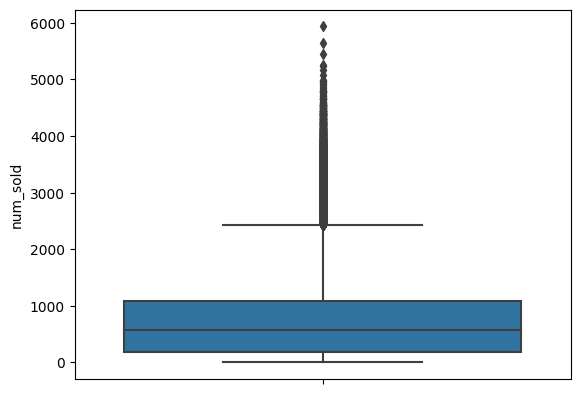

In [34]:
sns.boxplot(data=train_df_without_na, y="num_sold")

# DATA transformation

In [35]:
# See which columns are type categorical and store them
s = (train_df_without_na.dtypes == 'object')
object_cols = list(s[s].index)
print(f"Categorical variables:\n{object_cols}")

Categorical variables:
['country', 'store', 'product']


In [36]:
split_date = '2014-01-02'

data_train = train_df_without_na.copy()
data_train = data_train.sort_values('id')

split_train = data_train[data_train['date'] < split_date]
split_val = data_train[data_train['date'] >= split_date]

In [37]:
from sklearn.model_selection import KFold

def target_encode_group_oof(df, group_cols, target_col, n_splits=5, smoothing=10, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    encoded = pd.Series(index=df.index, dtype=float)
    global_mean = df[target_col].mean()

    for train_idx, val_idx in kf.split(df):
        fold_train = df.iloc[train_idx]

        means = fold_train.groupby(group_cols)[target_col].mean()
        counts = fold_train.groupby(group_cols)[target_col].count()

        smoothed = (means * counts + global_mean * smoothing) / (counts + smoothing)

        val_keys = df.iloc[val_idx][group_cols].apply(tuple, axis=1)
        smoothed_dict = smoothed.to_dict()
        encoded.iloc[val_idx] = val_keys.map(smoothed_dict).values

    return encoded.fillna(global_mean)

X_train_tar = split_train.copy()
X_test_tar = test_df.copy() 
X_val_tar = split_val.copy()


global_mean = X_train_tar['num_sold'].mean()

# Interaction encodings
X_train_tar['country_store_encoded'] = target_encode_group_oof(
    X_train_tar, ['country', 'store'], 'num_sold'
)
X_train_tar['store_product_encoded'] = target_encode_group_oof(
    X_train_tar, ['store', 'product'], 'num_sold'
)
X_train_tar['country_product_encoded'] = target_encode_group_oof(
    X_train_tar, ['country', 'product'], 'num_sold'
)

X_train_tar['country_store_product_encoded'] = target_encode_group_oof(
    X_train_tar, ['country', 'store', 'product'], 'num_sold', smoothing=20 
)
def build_group_encoding_map(df, group_cols, target_col, smoothing, global_mean):
    means = df.groupby(group_cols)[target_col].mean()
    counts = df.groupby(group_cols)[target_col].count()
    return (means * counts + global_mean * smoothing) / (counts + smoothing)

cs_map = build_group_encoding_map(X_train_tar, ['country', 'store'], 'num_sold', 20, global_mean)
sp_map = build_group_encoding_map(X_train_tar, ['store', 'product'], 'num_sold', 20, global_mean)
cp_map = build_group_encoding_map(X_train_tar, ['country', 'product'], 'num_sold', 20, global_mean)
csp_map = build_group_encoding_map(X_train_tar, ['country', 'store', 'product'], 'num_sold', 20, global_mean)

X_test_tar['country_store_encoded'] = X_test_tar[['country', 'store']].apply(tuple, axis=1).map(cs_map).fillna(global_mean)
X_test_tar['store_product_encoded'] = X_test_tar[['store', 'product']].apply(tuple, axis=1).map(sp_map).fillna(global_mean)
X_test_tar['country_product_encoded'] = X_test_tar[['country', 'product']].apply(tuple, axis=1).map(cp_map).fillna(global_mean)
X_test_tar['country_store_product_encoded'] = X_test_tar[['country', 'store', 'product']].apply(tuple, axis=1).map(csp_map).fillna(global_mean)

X_val_tar['country_store_encoded'] = X_val_tar[['country', 'store']].apply(tuple, axis=1).map(cs_map).fillna(global_mean)
X_val_tar['store_product_encoded'] = X_val_tar[['store', 'product']].apply(tuple, axis=1).map(sp_map).fillna(global_mean)
X_val_tar['country_product_encoded'] = X_val_tar[['country', 'product']].apply(tuple, axis=1).map(cp_map).fillna(global_mean)
X_val_tar['country_store_product_encoded'] = X_val_tar[['country', 'store', 'product']].apply(tuple, axis=1).map(csp_map).fillna(global_mean)


In [38]:
from sklearn.preprocessing import TargetEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[('target_enc', TargetEncoder(smooth='auto', target_type='continuous'), object_cols)], remainder='drop')
X_train_tar_v2 = preprocessor.fit_transform(X_train_tar.drop('num_sold', axis=1), X_train_tar['num_sold'])
X_test_tar_v2 = preprocessor.transform(X_test_tar)
X_val_tar_v2 = preprocessor.transform(X_val_tar)


feature_names = preprocessor.get_feature_names_out()

X_train_tar_v2 = pd.DataFrame(
    X_train_tar_v2, 
    columns=feature_names,
    index=X_train_tar.index
).astype(float)

X_test_tar_v2 = pd.DataFrame(
    X_test_tar_v2, 
    columns=feature_names,
    index=X_test_tar.index
).astype(float)

X_val_tar_v2 = pd.DataFrame(
    X_val_tar_v2, 
    columns=feature_names,
    index=X_val_tar.index
).astype(float)

X_train_tar_v2 = X_train_tar_v2.apply(pd.to_numeric)
X_test_tar_v2 = X_test_tar_v2.apply(pd.to_numeric)
X_val_tar_v2 = X_val_tar_v2.apply(pd.to_numeric)

X_train_tarenc = pd.concat([X_train_tar, X_train_tar_v2, split_train.drop(['num_sold', 'id', 'date', 'country',
                                                                                  'store', 'product'], axis=1)], axis=1)
X_test_tarenc = pd.concat([X_test_tar, X_test_tar_v2, test_df.drop(['id', 'date', 'country', 'store', 'product'], axis=1)], axis=1)

X_val_tarenc = pd.concat([X_val_tar, X_val_tar_v2, split_val.drop(['num_sold', 'id', 'date', 'country',
                                                                                  'store', 'product'], axis=1)], axis=1)

print("Train DataFrame shape:", X_train_tarenc.shape)
print("Test DataFrame shape:", X_test_tarenc.shape)
print("Validation DataFrame shape:", X_val_tarenc.shape)


Train DataFrame shape: (131580, 13)
Test DataFrame shape: (98550, 12)
Validation DataFrame shape: (98550, 13)


In [39]:
#Create a new column to differentiate the three dataFrame and join them
X_train_tarenc['df'] = 'train'
X_test_tarenc['df'] = 'test'
X_val_tarenc['df'] = 'val'
df_merged = pd.concat([X_train_tarenc, X_test_tarenc,X_val_tarenc], ignore_index=True)
df_merged = df_merged.reset_index(drop=True)

#add a time-step feature 
df_merged = df_merged.sort_values(['country', 'store', 'product', 'date'])
df_merged['Time'] = df_merged.groupby(['country', 'store', 'product']).cumcount() 

#Use the function create_features to get time features
df_merged = create_features(df_merged)

df_merged.shape

(328680, 22)

In [40]:
# see new dataframe columns
print(f"Dataframe columns:\n{df_merged.columns}")

Dataframe columns:
Index(['id', 'date', 'country', 'store', 'product', 'num_sold',
       'country_store_encoded', 'store_product_encoded',
       'country_product_encoded', 'country_store_product_encoded',
       'target_enc__country', 'target_enc__store', 'target_enc__product', 'df',
       'Time', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear',
       'dayofmonth', 'weekofyear'],
      dtype='object')


In [41]:
# set variable y and x for the training data
df_merged=df_merged.sort_values(by='id')
y_train = df_merged[df_merged['df']=='train'].num_sold
y_val = df_merged[df_merged['df']=='val'].num_sold
df_x = df_merged.drop('num_sold', axis=1).copy()

In [42]:
#Transforming the categorical variables from the test and training data into numerical
import sklearn
from sklearn.preprocessing import OneHotEncoder
OH_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, feature_name_combiner='concat')
OH_array  = OH_encoder.fit_transform(df_x[object_cols])
OH_cols_df = pd.DataFrame(OH_array, columns=OH_encoder.get_feature_names_out(object_cols), index=df_x.index
)
OH_cols_df

,country_Canada,country_Finland,country_Italy,country_Kenya,country_Norway,country_Singapore,store_Discount Stickers,store_Premium Sticker Mart,store_Stickers for Less,product_Holographic Goose,product_Kaggle,product_Kaggle Tiers,product_Kerneler,product_Kerneler Dark Mode
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230125,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
230126,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
230127,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
230128,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [43]:
#Merge the categorical variables with the other variables
OH_cols_df.index = df_x.index

num_x_df = df_x.drop(object_cols, axis=1)

OH_x_df = pd.concat([num_x_df, OH_cols_df], axis=1)

OH_x_df.columns = OH_x_df.columns.astype(str)

OH_x_df.columns

Index(['id', 'date', 'country_store_encoded', 'store_product_encoded',
       'country_product_encoded', 'country_store_product_encoded',
       'target_enc__country', 'target_enc__store', 'target_enc__product', 'df',
       'Time', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear',
       'dayofmonth', 'weekofyear', 'country_Canada', 'country_Finland',
       'country_Italy', 'country_Kenya', 'country_Norway', 'country_Singapore',
       'store_Discount Stickers', 'store_Premium Sticker Mart',
       'store_Stickers for Less', 'product_Holographic Goose',
       'product_Kaggle', 'product_Kaggle Tiers', 'product_Kerneler',
       'product_Kerneler Dark Mode'],
      dtype='object')

In [44]:
#Make sure there isn't no NAs
print(f"NAs num_sold: {y_train.isnull().sum()} \n\n NAs varialbes: \n{OH_x_df.isnull().sum()}")


NAs num_sold: 0 

 NAs varialbes: 
id                               0
date                             0
country_store_encoded            0
store_product_encoded            0
country_product_encoded          0
country_store_product_encoded    0
target_enc__country              0
target_enc__store                0
target_enc__product              0
df                               0
Time                             0
dayofweek                        0
quarter                          0
month                            0
year                             0
dayofyear                        0
dayofmonth                       0
weekofyear                       0
country_Canada                   0
country_Finland                  0
country_Italy                    0
country_Kenya                    0
country_Norway                   0
country_Singapore                0
store_Discount Stickers          0
store_Premium Sticker Mart       0
store_Stickers for Less          0
product_Holographic 

In [45]:
#Separate the test data and training data
X_train = OH_x_df[OH_x_df['df']=='train'].drop(['id', 'df', 'date'], axis=1).copy()
X_test = OH_x_df[OH_x_df['df']=='test'].drop(['id', 'df', 'date'], axis=1).copy()
X_val = OH_x_df[OH_x_df['df']=='val'].drop(['id', 'df', 'date'], axis=1).copy()

In [46]:
import joblib
import json
import optuna
import optuna.visualization as vis
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    mean_absolute_percentage_error, root_mean_squared_error,
    root_mean_squared_log_error
)
from sklearn.model_selection import cross_val_score, learning_curve, TimeSeriesSplit
from optuna.pruners import MedianPruner
from functools import partial

# Kaggle directory for saving files
Output_directory= '/kaggle/working/'

# Save dataframes
X_train.to_parquet(f'{Output_directory}X_train.parquet')
X_test.to_parquet(f'{Output_directory}X_test.parquet')
X_val.to_parquet(f'{Output_directory}X_val.parquet')
y_train.to_frame(name='sales').to_parquet(f'{Output_directory}y_train.parquet')
y_val.to_frame(name='sales').to_parquet(f'{Output_directory}y_val.parquet')

# Time-based validation: respects chronological order, never validates on data prior to that fold's train set
tscv = TimeSeriesSplit(n_splits=5)
    
# Pruner
pruner = MedianPruner(
    n_startup_trials=8,
    n_warmup_steps=2,
    interval_steps=1,
    n_min_trials=8,
)

# Early stopping: stops the whole study if the best value hasn't improved in the last `patience` trials
def early_stopping(study, trial, patience=30, start_trial_number=0):
    trials_since_start = trial.number - start_trial_number
    if trials_since_start < patience:
        return

    best_trial_number = study.best_trial.number
    if best_trial_number < start_trial_number:
        trials_without_improvement = trials_since_start
    else:
        trials_without_improvement = trial.number - best_trial_number

    if trials_without_improvement >= patience:
        print(f"No improvement in the last {patience} trials. Stopping study.")
        study.stop()
#Sampler with seed for every model
sampler= optuna.samplers.TPESampler(seed=42)

#####################################################################
# METRICS
#####################################################################

def cross_val(model, X_train, y_train, name=""):
    scores = -cross_val_score(model, X_train, y_train, cv=tscv, scoring='neg_root_mean_squared_error')
    print(f"--- {name}: Cross-validation (5 folds) ---")
    print(f"RMSE por fold: {np.round(scores, 4)}")
    print(f"Media: {scores.mean():.4f} | Std: {scores.std():.4f} | CV%: {scores.std()/scores.mean()*100:.2f}%")
    return {'cv_mean': scores.mean(), 'cv_std': scores.std()}
def cross_val_xgb(params, X, y, tscv):
    scores = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):

        X_tr = X.iloc[train_idx]
        X_va = X.iloc[val_idx]
        y_tr = y.iloc[train_idx]
        y_va = y.iloc[val_idx]

        model = xgb.XGBRegressor(
            **params,
            random_state=42,
            early_stopping_rounds=30
        )

        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_va, y_va)],
            verbose=False
        )

        pred = model.predict(X_va)
        rmse = root_mean_squared_error(y_va, pred)
        scores.append(rmse)

        print(f"Fold {fold + 1}: {rmse:.4f}")

    print(f"CV mean: {np.mean(scores):.4f}")
    print(f"CV std: {np.std(scores):.4f}")

    return np.array(scores)
def plot_learning_curve(model, X_train, y_train, name=""):

    model_lc = xgb.XGBRegressor(
        **model.get_params()
    )

    # Remove early stopping
    model_lc.set_params(early_stopping_rounds=None)

    train_sizes, train_scores, val_scores = learning_curve(
        model_lc,
        X_train,
        y_train,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    train_rmse = -train_scores.mean(axis=1)
    val_rmse = -val_scores.mean(axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_rmse, label="Train RMSE")
    plt.plot(train_sizes, val_rmse, label="Validation RMSE")
    plt.xlabel("Training samples")
    plt.ylabel("RMSE")
    plt.title(f"Learning Curve - {name}")
    plt.legend()
    plt.show()
def evaluate_additional_metrics(y_true, y_pred, name=""):
    errors = y_true - y_pred
    error_pct = np.abs(errors / y_true) * 100

    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape_val = mean_absolute_percentage_error(y_true, y_pred) * 100
    try:
        rmsle = root_mean_squared_log_error(y_true, y_pred)
    except ValueError:
        rmsle = None  # fails if there are negative predictions

    print(f"--- {name}: Additional metrics ---")
    print(f"MAE: {mae:.4f} | MAPE: {mape_val:.2f}% | R²: {r2:.4f}", end="")
    print(f" | RMSLE: {rmsle:.4f}" if rmsle is not None else " | RMSLE: N/A (negative predictions)")
    print(f"Bias (mean error): {errors.mean():.4f}")
    print(f"Prediction std: {y_pred.std():.4f} | Real std: {y_true.std():.4f}")
    for tol in [10, 15, 20]:
        successes = (error_pct <= tol).mean() * 100
        print(f"Within ±{tol}%: {successes:.2f}%")
        
def evaluate_gap(y_train, pred_train, y_val, pred_val, name=""):
    rmse_train = root_mean_squared_error(y_train, pred_train)
    rmse_val = root_mean_squared_error(y_val, pred_val)
    gap = rmse_val - rmse_train
    gap_pct = gap / rmse_train * 100

    print(f"--- {name}: Train vs Val ---")
    print(f"RMSE train: {rmse_train:.4f} | RMSE val: {rmse_val:.4f}")
    print(f"Gap: {gap:.4f} ({gap_pct:.2f}%)")

    return {'rmse_train': rmse_train, 'rmse_val': rmse_val, 'gap_pct': gap_pct}


In [47]:
##############################################################
# 1. XGBoost
##############################################################
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'min_child_weight': trial.suggest_int('min_child_weight', 10, 100),
        'gamma': trial.suggest_float('gamma', 0.01, 10, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.2, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 20.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 10, 100.0, log=True),
        'random_state': 42,
    }
    
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**param, early_stopping_rounds=30)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],verbose=False)
        pred = model.predict(X_va)
        rmse = root_mean_squared_error(y_va, pred)
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

study_xgb = optuna.create_study(sampler=sampler,direction='minimize', pruner=pruner)
study_xgb.optimize(objective_xgb, n_trials=200, callbacks=[partial(early_stopping, patience=60)])
print(f"XGBoost best parameters: {study_xgb.best_params}")

#saves the study
joblib.dump(study_xgb, f'{Output_directory}study_xgb.pkl')

#Load study 
#study_xgb = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/study_xgb (1).pkl')

[I 2026-09-15 16:38:38,728] A new study created in memory with name: no-name-db633e67-04ae-489b-827a-6894e67f45b9
[I 2026-09-15 16:38:44,556] Trial 0 finished with value: 128.26719229148216 and parameters: {'n_estimators': 1436, 'learning_rate': 0.17254716573280354, 'max_depth': 4, 'min_child_weight': 64, 'gamma': 0.02938027938703535, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.4348501673009197, 'colsample_bylevel': 0.8929409166199482, 'reg_alpha': 0.3849583075868115, 'reg_lambda': 51.059032093947565}. Best is trial 0 with value: 128.26719229148216.
[I 2026-09-15 16:38:49,313] Trial 1 finished with value: 124.40625333768352 and parameters: {'n_estimators': 551, 'learning_rate': 0.18276027831785724, 'max_depth': 5, 'min_child_weight': 29, 'gamma': 0.035113563139704075, 'subsample': 0.5917022549267169, 'colsample_bytree': 0.5825453457757226, 'colsample_bylevel': 0.6198051453057902, 'reg_alpha': 0.07207895500630218, 'reg_lambda': 19.55370866274525}. Best is trial 1 with value: 

No improvement in the last 60 trials. Stopping study.
XGBoost best parameters: {'n_estimators': 2734, 'learning_rate': 0.16554880211282758, 'max_depth': 5, 'min_child_weight': 21, 'gamma': 1.9999212068331877, 'subsample': 0.8595821409312292, 'colsample_bytree': 0.5136120743384065, 'colsample_bylevel': 0.27533311496673085, 'reg_alpha': 0.0027228954919143998, 'reg_lambda': 13.23065309429973}


['/kaggle/working/study_xgb.pkl']

In [48]:
print(f"Trials executed: {len(study_xgb.trials)}")
print(f"Best trial: {study_xgb.best_trial.number}")
print(f"Best RMSE: {study_xgb.best_value:.4f}")
print(f"Best parameters: {study_xgb.best_params}")

Trials executed: 107
Best trial: 46
Best RMSE: 116.7035
Best parameters: {'n_estimators': 2734, 'learning_rate': 0.16554880211282758, 'max_depth': 5, 'min_child_weight': 21, 'gamma': 1.9999212068331877, 'subsample': 0.8595821409312292, 'colsample_bytree': 0.5136120743384065, 'colsample_bylevel': 0.27533311496673085, 'reg_alpha': 0.0027228954919143998, 'reg_lambda': 13.23065309429973}


In [49]:
df_trials_xgb = study_xgb.trials_dataframe()
print(df_trials_xgb[['number', 'value','state']].tail(15))

     number       value     state
92       92  139.790007    PRUNED
93       93  117.760770  COMPLETE
94       94  117.930317  COMPLETE
95       95  135.463597    PRUNED
96       96  137.919848    PRUNED
97       97  145.261468    PRUNED
98       98  136.240585    PRUNED
99       99  140.709342    PRUNED
100     100  142.338704    PRUNED
101     101  136.807601    PRUNED
102     102  139.378842    PRUNED
103     103  118.801847  COMPLETE
104     104  118.189323  COMPLETE
105     105  136.955521    PRUNED
106     106  137.849220    PRUNED


In [50]:
vis.plot_optimization_history(study_xgb).show()
vis.plot_param_importances(study_xgb).show()

/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning:

invalid value encountered in less



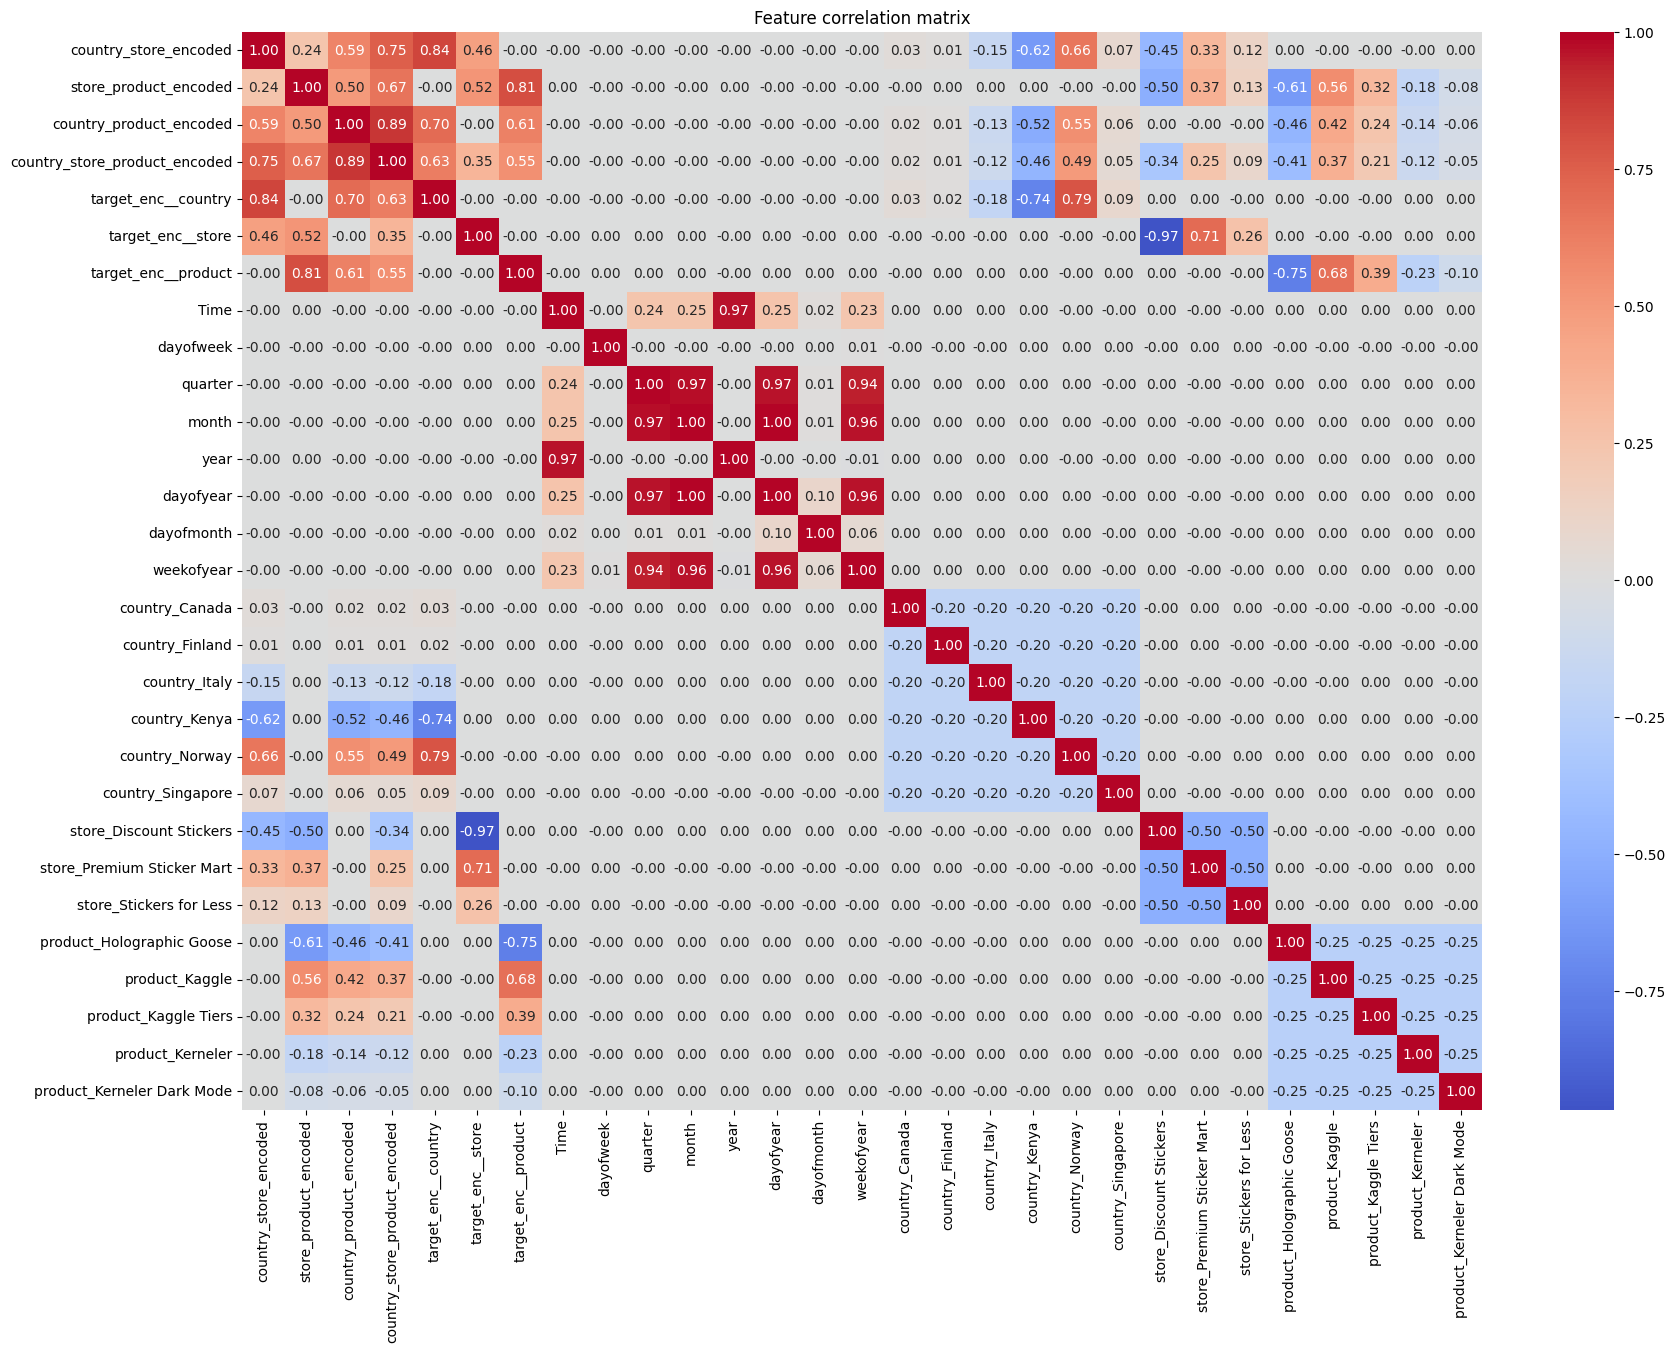

In [51]:
# Autocorrelation matrix
corr_matrix = X_train.corr()

plt.figure(figsize=(20, 14))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,  fmt='.2f', annot=True)
plt.title('Feature correlation matrix')
plt.show()


In [52]:
#Creat a dataframe to fit de model with the best params
# 80% for training
split = int(len(X_train) * 0.8)

df_train = X_train.iloc[:split].copy()
y_tr = y_train.iloc[:split].copy()

# 20% early stopping
df_val = X_train.iloc[split:].copy()
y_va = y_train.iloc[split:].copy()   

model_xgb = xgb.XGBRegressor(**study_xgb.best_params, random_state=42, early_stopping_rounds=30)
model_xgb.fit(df_train, y_tr, eval_set=[(df_val, y_va)],verbose=False)
joblib.dump(model_xgb, f'{Output_directory}model_xgb.pkl')

#Load study 
#model_xgb = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/model_xgb.pkl')

['/kaggle/working/model_xgb.pkl']

--- XGBoost: Train vs Val ---
RMSE train: 71.5713 | RMSE val: 181.2595
Gap: 109.6882 (153.26%)
--- XGBoost: Additional metrics ---
MAE: 96.3595 | MAPE: 817641567150515840.00% | R²: 0.9202 | RMSLE: N/A (negative predictions)
Bias (mean error): -63.2443
Prediction std: 726.1292 | Real std: 641.8150
Within ±10%: 44.51%
Within ±15%: 58.40%
Within ±20%: 66.89%
Fold 1: 155.8648
Fold 2: 115.5081
Fold 3: 116.6898
Fold 4: 96.5720
Fold 5: 98.8828
CV mean: 116.7035
CV std: 21.2504


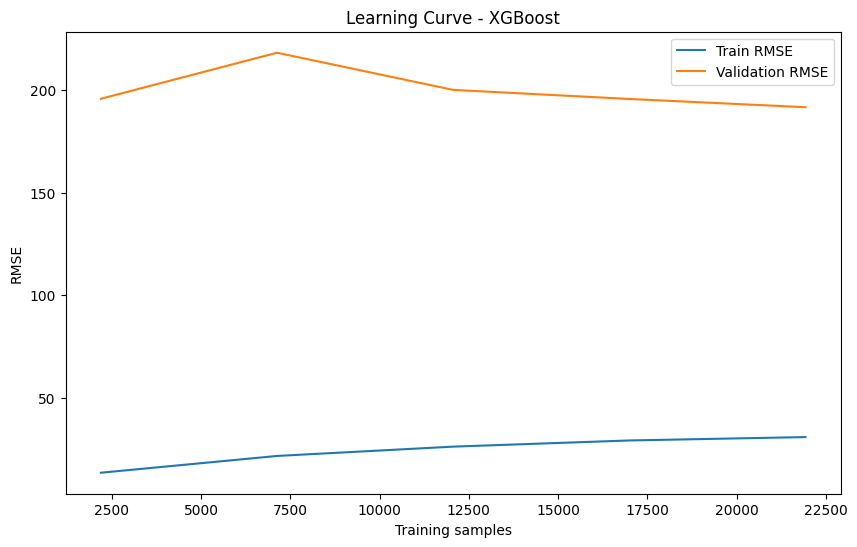

In [53]:
pred_train_xgb = model_xgb.predict(X_train)
pred_val_xgb = model_xgb.predict(X_val)
gap_xgb = evaluate_gap(y_train, pred_train_xgb, y_val, pred_val_xgb, "XGBoost")
addmet_xgb_trget = evaluate_additional_metrics(y_val, pred_val_xgb, "XGBoost")
cv_xgb = cross_val_xgb(
    study_xgb.best_params,
    X_train,
    y_train,
    tscv)
plot_learning_curve(model_xgb, X_train, y_train, "XGBoost")


In [54]:
results = pd.DataFrame({
    'date': data_train.loc[data_train['date'] >= split_date, 'date'].values,
    'y_true': y_val.values,
    'y_pred': pred_val_xgb
})

results['year'] = results['date'].dt.year

rmse_by_year = (
    results.groupby('year')
    .apply(lambda x: root_mean_squared_error(x['y_true'], x['y_pred']))
)

print(rmse_by_year)

year
2014     88.352627
2015    191.929500
2016    231.939401
dtype: float64


<ipython-input-54-38f075c88f8d>:11: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [55]:
print(
    results.groupby('year')['y_true']
    .agg(['mean', 'median', 'std', 'min', 'max', 'count'])
)

            mean  median         std  min     max  count
year                                                    
2014  747.661844   600.0  706.087613  0.0  5643.0  32760
2015  666.152390   526.0  619.874054  0.0  3996.0  32850
2016  653.438767   528.0  590.076990  0.0  3466.0  32940


In [56]:
print(
    results.groupby('year')['y_pred']
    .agg(['mean', 'median', 'std', 'min', 'max'])
)

            mean      median         std        min          max
year                                                            
2014  751.660889  593.229187  725.373657 -49.022495  4743.399902
2015  751.958679  593.320435  725.822937 -48.658272  4612.486328
2016  753.104370  593.666077  727.217224 -43.591022  4651.503906


In [57]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(model_xgb, X_val, y_val, random_state=42, n_repeats=10)
#Load study 
#perm = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/permutation_result.pkl')
feature_importances = pd.DataFrame({
    'feature': X_val.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values(by='importance_mean', ascending=False)

joblib.dump(perm, f'{Output_directory}permutation_result.pkl')

print(feature_importances)

                          feature  importance_mean  importance_std
1           store_product_encoded         0.080241        0.000672
4             target_enc__country         0.045002        0.000621
8                       dayofweek         0.030808        0.000613
6             target_enc__product         0.025985        0.000421
3   country_store_product_encoded         0.020997        0.000325
2         country_product_encoded         0.017146        0.000260
18                  country_Kenya         0.010167        0.000180
20              country_Singapore         0.007401        0.000055
24      product_Holographic Goose         0.007383        0.000292
10                          month         0.004901        0.000127
14                     weekofyear         0.003530        0.000078
12                      dayofyear         0.003059        0.000106
27               product_Kerneler         0.002778        0.000074
26           product_Kaggle Tiers         0.001832        0.00

In [58]:
import shap

SAMPLE_SIZE = 5000
X_train_sample = X_train.sample(n=SAMPLE_SIZE, random_state=42)

explainer_lgb = shap.TreeExplainer(model_xgb)
shap_values_lgb = explainer_lgb.shap_values(X_train_sample, check_additivity=False)

shap_lgb = pd.DataFrame({
    'feature': X_train_sample.columns,
    'mean_abs_shap': np.abs(shap_values_lgb).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

shap_lgb['pct'] = shap_lgb['mean_abs_shap'] / shap_lgb['mean_abs_shap'].sum() * 100

print(shap_lgb)

# Flag features below a threshold as candidates for removal
UMBRAL_PCT = 0.5  # adjust as needed

candidatas_a_eliminar = shap_lgb[shap_lgb['pct'] < UMBRAL_PCT]['feature'].tolist()
print(f"\nCandidate features to drop (< {UMBRAL_PCT}% of total importance):")
print(candidatas_a_eliminar)

                          feature  mean_abs_shap        pct
0           store_product_encoded     117.141197  12.076405
1   country_store_product_encoded     116.474403  12.007663
2         country_product_encoded     110.427902  11.384313
3             target_enc__country      82.308746   8.485433
4             target_enc__product      77.851280   8.025900
5           country_store_encoded      63.331032   6.528968
6       product_Holographic Goose      54.306137   5.598567
7                       dayofweek      49.108307   5.062709
8               target_enc__store      46.708420   4.815298
9                  country_Norway      39.245102   4.045884
10                  country_Kenya      37.822155   3.899189
11        store_Discount Stickers      30.783493   3.173554
12                           year      24.084497   2.482936
13                           Time      17.948334   1.850343
14                 product_Kaggle      16.389154   1.689602
15                  country_Italy      1

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

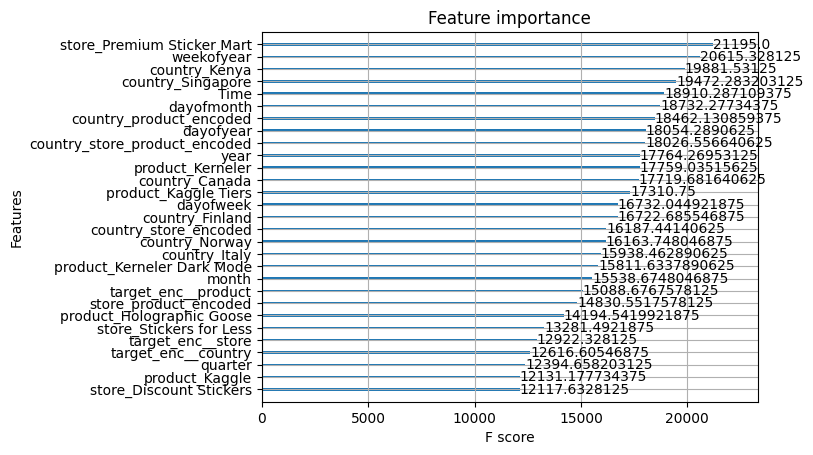

In [59]:
xgb.plot_importance(model_xgb, importance_type='cover')

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

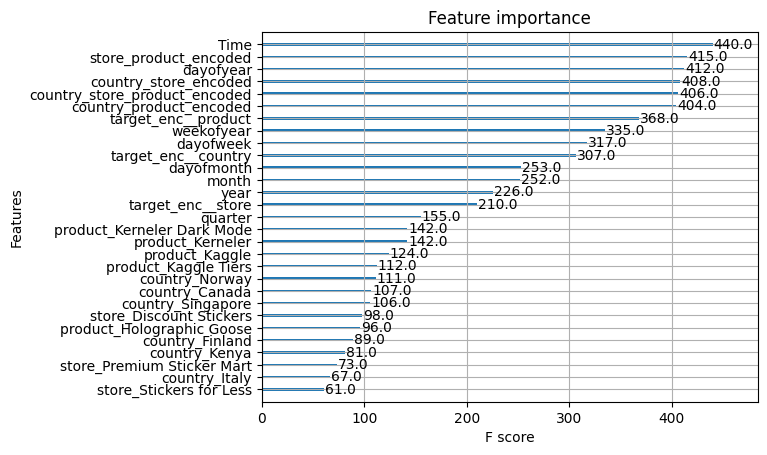

In [60]:
xgb.plot_importance(model_xgb, importance_type='weight')

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

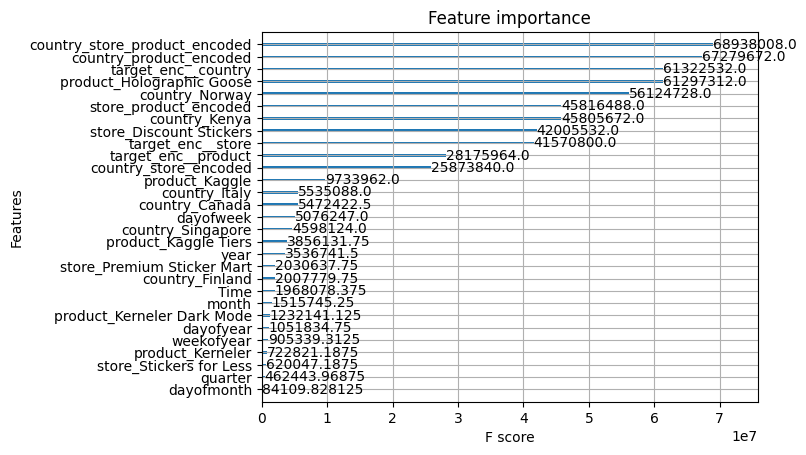

In [61]:
xgb.plot_importance(model_xgb, importance_type='gain')

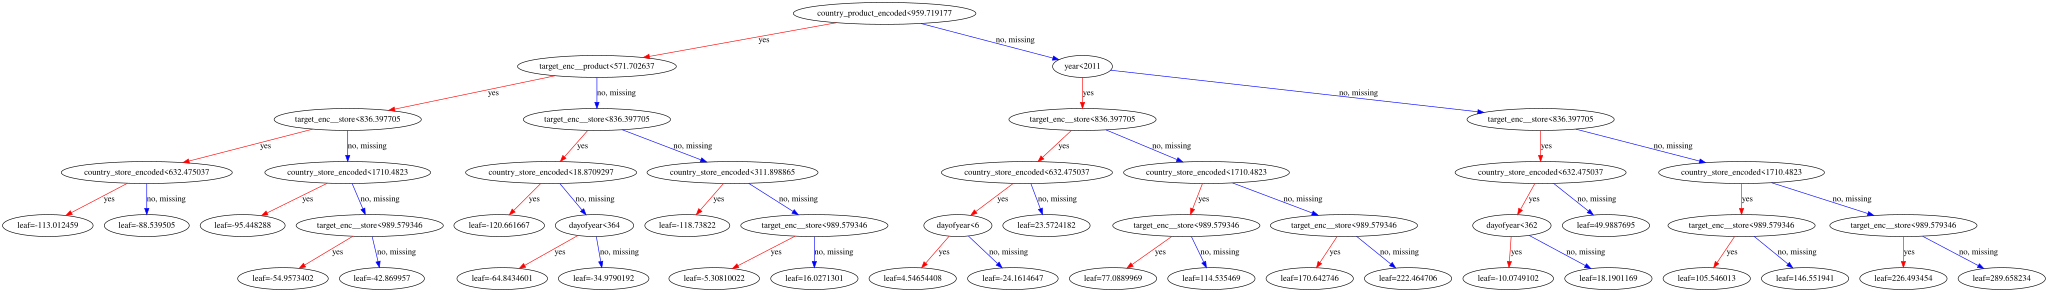

In [62]:
xgb.to_graphviz(model_xgb, num_trees=0)

In [63]:
#Target encoded dataframe
X_train_target = X_train.drop(['country_Canada', 'country_Finland','country_Italy',
                                                   'country_Kenya', 'country_Norway', 'country_Singapore',
                                                   'store_Discount Stickers', 'store_Premium Sticker Mart',
                                                   'store_Stickers for Less', 'product_Holographic Goose', 'product_Kaggle',
                                                   'product_Kaggle Tiers', 'product_Kerneler', 'product_Kerneler Dark Mode'], axis=1).copy()

X_val_target = X_val.drop(['country_Canada', 'country_Finland','country_Italy',
                                                   'country_Kenya', 'country_Norway', 'country_Singapore',
                                                   'store_Discount Stickers', 'store_Premium Sticker Mart',
                                                   'store_Stickers for Less', 'product_Holographic Goose', 'product_Kaggle',
                                                   'product_Kaggle Tiers', 'product_Kerneler', 'product_Kerneler Dark Mode'], axis=1).copy()
    

In [64]:
# 1. XGBoost with only target encoding 
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'min_child_weight': trial.suggest_int('min_child_weight', 10, 100),
        'gamma': trial.suggest_float('gamma', 0.01, 10, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.2, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 20.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 10, 100.0, log=True),
        'random_state': 42,
    }
    
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(df_train)):
        X_tr, X_va = df_train.iloc[train_idx], df_train.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**param, early_stopping_rounds=30)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        pred = model.predict(X_va)
        rmse = root_mean_squared_error(y_va, pred)
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

study_xgb_target = optuna.create_study(sampler=sampler,direction='minimize', pruner=pruner)
study_xgb_target.optimize(objective_xgb, n_trials=200, callbacks=[partial(early_stopping, patience=60)])
print(f"XGBoost best parameters: {study_xgb_target.best_params}")

# saves the study
joblib.dump(study_xgb_target, f'{Output_directory}study_xgb_target.pkl')

#Load study 
#study_xgb_target = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/study_xgb_target.pkl')

[I 2026-09-15 16:51:22,361] A new study created in memory with name: no-name-a5914366-3143-48c1-919e-a3e79d761574
[I 2026-09-15 16:51:37,837] Trial 0 finished with value: 108.65766339963909 and parameters: {'n_estimators': 578, 'learning_rate': 0.06729596646792112, 'max_depth': 3, 'min_child_weight': 56, 'gamma': 5.280796376895363, 'subsample': 0.6246461145744375, 'colsample_bytree': 0.6462297538213778, 'colsample_bylevel': 0.804440910834439, 'reg_alpha': 0.009639794432729033, 'reg_lambda': 11.93932872653544}. Best is trial 0 with value: 108.65766339963909.
[I 2026-09-15 16:52:21,524] Trial 1 finished with value: 105.63292997773362 and parameters: {'n_estimators': 1224, 'learning_rate': 0.01620890700720353, 'max_depth': 5, 'min_child_weight': 83, 'gamma': 0.7947147424653744, 'subsample': 0.9357302950938589, 'colsample_bytree': 0.8822032461394687, 'colsample_bylevel': 0.3492560471088287, 'reg_alpha': 6.901174761956772, 'reg_lambda': 34.621209972935944}. Best is trial 1 with value: 105.6

XGBoost best parameters: {'n_estimators': 867, 'learning_rate': 0.14634174602102099, 'max_depth': 5, 'min_child_weight': 12, 'gamma': 0.028192251731460394, 'subsample': 0.9608696761448329, 'colsample_bytree': 0.6977518398772583, 'colsample_bylevel': 0.7938106808599552, 'reg_alpha': 9.39768321756074, 'reg_lambda': 34.1062407183037}


['/kaggle/working/study_xgb_target.pkl']

In [65]:
print(f"Trials executed: {len(study_xgb_target.trials)}")
print(f"Best trial: {study_xgb_target.best_trial.number}")
print(f"Best RMSE: {study_xgb_target.best_value:.4f}")
print(f"Best parameters: {study_xgb_target.best_params}")

Trials executed: 200
Best trial: 179
Best RMSE: 95.2402
Best parameters: {'n_estimators': 867, 'learning_rate': 0.14634174602102099, 'max_depth': 5, 'min_child_weight': 12, 'gamma': 0.028192251731460394, 'subsample': 0.9608696761448329, 'colsample_bytree': 0.6977518398772583, 'colsample_bylevel': 0.7938106808599552, 'reg_alpha': 9.39768321756074, 'reg_lambda': 34.1062407183037}


In [66]:
#Creat a dataframe to fit de model with the best params
# 80% for training
split = int(len(X_train_target) * 0.8)

df_train = X_train_target.iloc[:split].copy()
y_tr = y_train.iloc[:split].copy()

# 20% early stopping
df_val = X_train_target.iloc[split:].copy()
y_va = y_train.iloc[split:].copy()   

model_xgb_target = xgb.XGBRegressor(**study_xgb_target.best_params, random_state=42, early_stopping_rounds=30)
model_xgb_target.fit(df_train, y_tr, eval_set=[(df_val, y_va)],verbose=False)
joblib.dump(model_xgb_target, f'{Output_directory}model_xgb_target.pkl')

#Load study 
#model_xgb_target = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/model_xgb.pkl')

['/kaggle/working/model_xgb_target.pkl']

--- XGBoost: Train vs Val ---
RMSE train: 73.4894 | RMSE val: 179.6700
Gap: 106.1806 (144.48%)
--- XGBoost: Additional metrics ---
MAE: 95.2731 | MAPE: 816624483952589440.00% | R²: 0.9216 | RMSLE: N/A (negative predictions)
Bias (mean error): -59.7427
Prediction std: 722.5691 | Real std: 641.8150
Within ±10%: 44.97%
Within ±15%: 59.24%
Within ±20%: 67.98%
Fold 1: 168.0959
Fold 2: 127.9048
Fold 3: 124.3172
Fold 4: 92.5731
Fold 5: 108.8681
CV mean: 124.3518
CV std: 25.2024


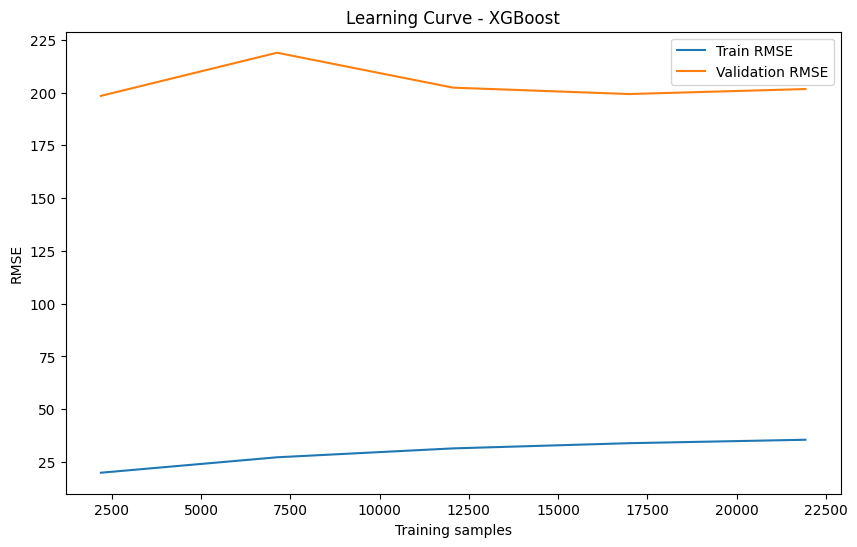

In [67]:
pred_train_xgb_target = model_xgb_target.predict(X_train_target)
pred_val_xgb_target = model_xgb_target.predict(X_val_target)
gap_xgb_target = evaluate_gap(y_train, pred_train_xgb_target, y_val, pred_val_xgb_target, "XGBoost")
addmet_xgb_target = evaluate_additional_metrics(y_val, pred_val_xgb_target, "XGBoost")
cv_xgb = cross_val_xgb(
    study_xgb_target.best_params,
    X_train_target,
    y_train,
    tscv)
plot_learning_curve(model_xgb_target, X_train_target, y_train, "XGBoost")


In [68]:
perm_xgb_target = permutation_importance(model_xgb_target, X_val_target, y_val, random_state=42, n_repeats=10)
#Load study 
#perm_xgb_target= joblib.load('/kaggle/input/datasets/davibaca/study-xgb/permutation_result.pkl')
feature_importances = pd.DataFrame({
    'feature': X_val_target.columns,
    'importance_mean': perm_xgb_target.importances_mean,
    'importance_std': perm_xgb_target.importances_std
}).sort_values(by='importance_mean', ascending=False)

joblib.dump(perm_xgb_target, f'{Output_directory}permutation_result_xgb_target.pkl')

print(feature_importances)

                          feature  importance_mean  importance_std
2         country_product_encoded         0.209399        0.001101
0           country_store_encoded         0.099499        0.000835
3   country_store_product_encoded         0.078333        0.000439
8                       dayofweek         0.029235        0.000594
6             target_enc__product         0.011093        0.000258
12                      dayofyear         0.007824        0.000134
1           store_product_encoded         0.005702        0.000368
14                     weekofyear         0.003508        0.000085
5               target_enc__store         0.002509        0.000228
10                          month         0.000725        0.000063
9                         quarter         0.000510        0.000020
7                            Time         0.000000        0.000000
11                           year         0.000000        0.000000
13                     dayofmonth        -0.000137        0.00

In [69]:
#Onehot encoding dataframe
X_train_onehot = X_train.drop(['target_enc__store',
                                                  'target_enc__country', 'target_enc__product','country_store_encoded', 'store_product_encoded',
                                                  'country_product_encoded', 'country_store_product_encoded'], axis=1).copy()


X_val_onehot = X_val.drop(['target_enc__store',
                           'target_enc__country', 'target_enc__product','country_store_encoded', 'store_product_encoded',
                           'country_product_encoded', 'country_store_product_encoded'], axis=1).copy()

In [70]:
# 1. XGBoost with only onehot encoding
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'min_child_weight': trial.suggest_int('min_child_weight', 10, 100),
        'gamma': trial.suggest_float('gamma', 0.01, 10, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.2, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 20.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 10, 100.0, log=True),
        'random_state': 42,
    }
    
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_onehot)):
        X_tr, X_va = X_train_onehot.iloc[train_idx], X_train_onehot.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**param, early_stopping_rounds=30)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],verbose=False)
        pred = model.predict(X_va)
        rmse = root_mean_squared_error(y_va, pred)
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

study_xgb_onehot = optuna.create_study(sampler=sampler,direction='minimize', pruner=pruner)
study_xgb_onehot.optimize(objective_xgb, n_trials=200, callbacks=[partial(early_stopping, patience=60)])
print(f"XGBoost best parameters: {study_xgb_onehot.best_params}")

# saves the study
joblib.dump(study_xgb_onehot, f'{Output_directory}study_xgb_onehot.pkl')
#Load study 
#study_xgb_onehot = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/study_xgb_onehot.pkl')

[I 2026-09-15 17:29:02,122] A new study created in memory with name: no-name-01523123-d889-41b7-b199-7f0a39009135
[I 2026-09-15 17:30:12,079] Trial 0 finished with value: 216.7600515999173 and parameters: {'n_estimators': 2105, 'learning_rate': 0.012866742758077603, 'max_depth': 2, 'min_child_weight': 91, 'gamma': 0.6596099207886096, 'subsample': 0.5045985258083148, 'colsample_bytree': 0.4608829257196193, 'colsample_bylevel': 0.7308014152864446, 'reg_alpha': 0.0010514049659988579, 'reg_lambda': 14.481316698225731}. Best is trial 0 with value: 216.7600515999173.
[I 2026-09-15 17:30:25,663] Trial 1 finished with value: 134.8725504979085 and parameters: {'n_estimators': 1872, 'learning_rate': 0.0794650948407619, 'max_depth': 4, 'min_child_weight': 30, 'gamma': 1.3694231460024369, 'subsample': 0.6186245437484, 'colsample_bytree': 0.5952398188955607, 'colsample_bylevel': 0.7971931240944194, 'reg_alpha': 0.6224300978555493, 'reg_lambda': 70.66809927935715}. Best is trial 1 with value: 134.87

No improvement in the last 60 trials. Stopping study.
XGBoost best parameters: {'n_estimators': 1918, 'learning_rate': 0.13932194649483512, 'max_depth': 5, 'min_child_weight': 80, 'gamma': 0.010482092158182191, 'subsample': 0.6764504619469491, 'colsample_bytree': 0.9054310743747627, 'colsample_bylevel': 0.6198398837298705, 'reg_alpha': 10.83431597778563, 'reg_lambda': 50.284548336443684}


['/kaggle/working/study_xgb_onehot.pkl']

In [71]:
print(f"Trials executed: {len(study_xgb_onehot.trials)}")
print(f"Best trial: {study_xgb_onehot.best_trial.number}")
print(f"Best RMSE: {study_xgb_onehot.best_value:.4f}")
print(f"Best parameters: {study_xgb_onehot.best_params}")

Trials executed: 115
Best trial: 54
Best RMSE: 123.0580
Best parameters: {'n_estimators': 1918, 'learning_rate': 0.13932194649483512, 'max_depth': 5, 'min_child_weight': 80, 'gamma': 0.010482092158182191, 'subsample': 0.6764504619469491, 'colsample_bytree': 0.9054310743747627, 'colsample_bylevel': 0.6198398837298705, 'reg_alpha': 10.83431597778563, 'reg_lambda': 50.284548336443684}


In [72]:
#Creat a dataframe to fit de model with the best params
# 80% for training
split = int(len(X_train_onehot) * 0.8)

df_train = X_train_onehot.iloc[:split].copy()
y_tr = y_train.iloc[:split].copy()

# 20% early stopping
df_val = X_train_onehot.iloc[split:].copy()
y_va = y_train.iloc[split:].copy()   

model_xgb_onehot = xgb.XGBRegressor(**study_xgb_onehot.best_params, random_state=42, early_stopping_rounds=30)
model_xgb_onehot.fit(df_train, y_tr, eval_set=[(df_val, y_va)],verbose=False)
joblib.dump(model_xgb_onehot, f'{Output_directory}model_xgb_onehot.pkl')

#Load study 
#model_xgb_onehot = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/model_xgb.pkl')

['/kaggle/working/model_xgb_onehot.pkl']

--- XGBoost: Train vs Val ---
RMSE train: 69.8849 | RMSE val: 181.6029
Gap: 111.7180 (159.86%)
--- XGBoost: Additional metrics ---
MAE: 97.3146 | MAPE: 775654722557887360.00% | R²: 0.9199 | RMSLE: N/A (negative predictions)
Bias (mean error): -61.6494
Prediction std: 725.4440 | Real std: 641.8150
Within ±10%: 43.38%
Within ±15%: 57.54%
Within ±20%: 66.21%
Fold 1: 168.8140
Fold 2: 134.7070
Fold 3: 120.8286
Fold 4: 95.4621
Fold 5: 95.4784
CV mean: 123.0580
CV std: 27.4097


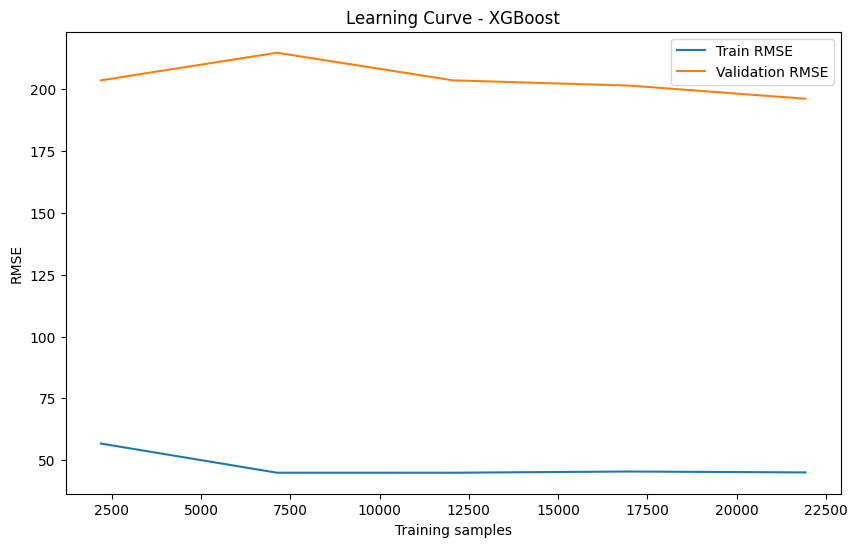

In [73]:
pred_train_xgb_onehot = model_xgb_onehot.predict(X_train_onehot)
pred_val_xgb_onehot = model_xgb_onehot.predict(X_val_onehot)
gap_xgb_onehot = evaluate_gap(y_train, pred_train_xgb_onehot, y_val, pred_val_xgb_onehot, "XGBoost")
addmet_xgb_onehot = evaluate_additional_metrics(y_val, pred_val_xgb_onehot, "XGBoost")
cv_xgb = cross_val_xgb(
    study_xgb_onehot.best_params,
    X_train_onehot,
    y_train,
    tscv)
plot_learning_curve(model_xgb_onehot, X_train_onehot, y_train, "XGBoost")


In [74]:
perm_xgb_onehot = permutation_importance(model_xgb_onehot, X_val_onehot, y_val, random_state=42, n_repeats=10)
#Load study 
#perm = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/permutation_result.pkl')
feature_importances= pd.DataFrame({
    'feature': X_val_onehot.columns,
    'importance_mean': perm_xgb_onehot.importances_mean,
    'importance_std': perm_xgb_onehot.importances_std
}).sort_values(by='importance_mean', ascending=False)

joblib.dump(perm_xgb_onehot, f'{Output_directory}permutation_result_xgb_onehot.pkl')

print(feature_importances)

                       feature  importance_mean  importance_std
12              country_Norway         0.456184        0.003108
11               country_Kenya         0.451622        0.002656
17   product_Holographic Goose         0.289828        0.001318
18              product_Kaggle         0.287700        0.001857
14     store_Discount Stickers         0.244094        0.002063
19        product_Kaggle Tiers         0.084883        0.000947
15  store_Premium Sticker Mart         0.045812        0.000953
10               country_Italy         0.041277        0.000303
1                    dayofweek         0.030193        0.000578
20            product_Kerneler         0.015475        0.000252
13           country_Singapore         0.011961        0.000087
5                    dayofyear         0.007435        0.000161
21  product_Kerneler Dark Mode         0.005636        0.000101
7                   weekofyear         0.005453        0.000080
3                        month         0